# SIM 3000s - Plot 16 only

Standalone notebook for the plot that shows `f` collapsing onto one curve and the random null-model comparison.

This version rebuilds the bar-fraction cache from the reduced files when the cache is empty or incomplete, so the plot can still be produced even if the original notebook stops early.

In [1]:
import os
import sys
import json
import pickle

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats
from scipy.signal import find_peaks
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components

sys.path.insert(0, os.path.abspath('..'))

RESULTS_DIR = '../I001_Results'
OBJ_DIR     = '../I001_Results/OBJ_files'
SIMS        = list(range(3000, 3010))
FAMILY_LABEL = 'SIM 3000s'

CACHE_BF   = 'bar_fraction_cache_3000s.pkl'
CACHE_NULL = 'random_percolation_null_3000s.pkl'
Q_C = (0.60, 0.65)
LOC_PROMINENCE_FRAC = 0.02

def load_pkl(path):
    if os.path.exists(path):
        with open(path, 'rb') as f:
            return pickle.load(f)
    fwd_file = os.path.join(RESULTS_DIR, 'AAA_fwd')
    if os.path.exists(fwd_file):
        with open(fwd_file) as f:
            fwd_dir = f.read().strip()
        fwd_path = os.path.join(fwd_dir, os.path.relpath(path, RESULTS_DIR))
        if os.path.exists(fwd_path):
            with open(fwd_path, 'rb') as f:
                return pickle.load(f)
    return None

def resolve_path(path):
    if os.path.exists(path):
        return path
    fwd_file = os.path.join(RESULTS_DIR, 'AAA_fwd')
    if os.path.exists(fwd_file):
        with open(fwd_file) as f:
            fwd_dir = f.read().strip()
        fwd_path = os.path.join(fwd_dir, os.path.relpath(path, RESULTS_DIR))
        if os.path.exists(fwd_path):
            return fwd_path
    return None

def get_pressure(sim):
    path = resolve_path(os.path.join(OBJ_DIR, f'SIM_{sim:03d}.json'))
    if path is None:
        return None
    with open(path) as f:
        d = json.load(f)
    for step in d.get('steps', []):
        pb = step.get('Pressure_BC', 0)
        if pb:
            return float(pb)
    return 0.0

def first_local_min(y, prominence_frac=None):
    y = np.asarray(y, dtype=float)
    frac = LOC_PROMINENCE_FRAC if prominence_frac is None else prominence_frac
    rng = float(y.max() - y.min())
    if rng > 0:
        idx, _ = find_peaks(-y, prominence=frac * rng)
        if len(idx):
            return int(idx[0])
    return int(np.argmin(y))

PRESSURES = {sim: get_pressure(sim) for sim in SIMS}
print({sim: f'{p:.6f} MPa' for sim, p in PRESSURES.items()})


{3000: '0.000000 MPa', 3001: '0.040000 MPa', 3002: '0.056569 MPa', 3003: '0.080000 MPa', 3004: '0.113137 MPa', 3005: '0.160000 MPa', 3006: '0.226274 MPa', 3007: '0.320000 MPa', 3008: '0.452548 MPa', 3009: '0.640000 MPa'}


Rebuilding bar-fraction cache from reduced files
Missing reduced files for sims: [3000, 3005, 3008]
loaded bar_fraction_cache_3000s.pkl (7 sims) and random_percolation_null_3000s.pkl (3 trials/point, 400 BFS sources)


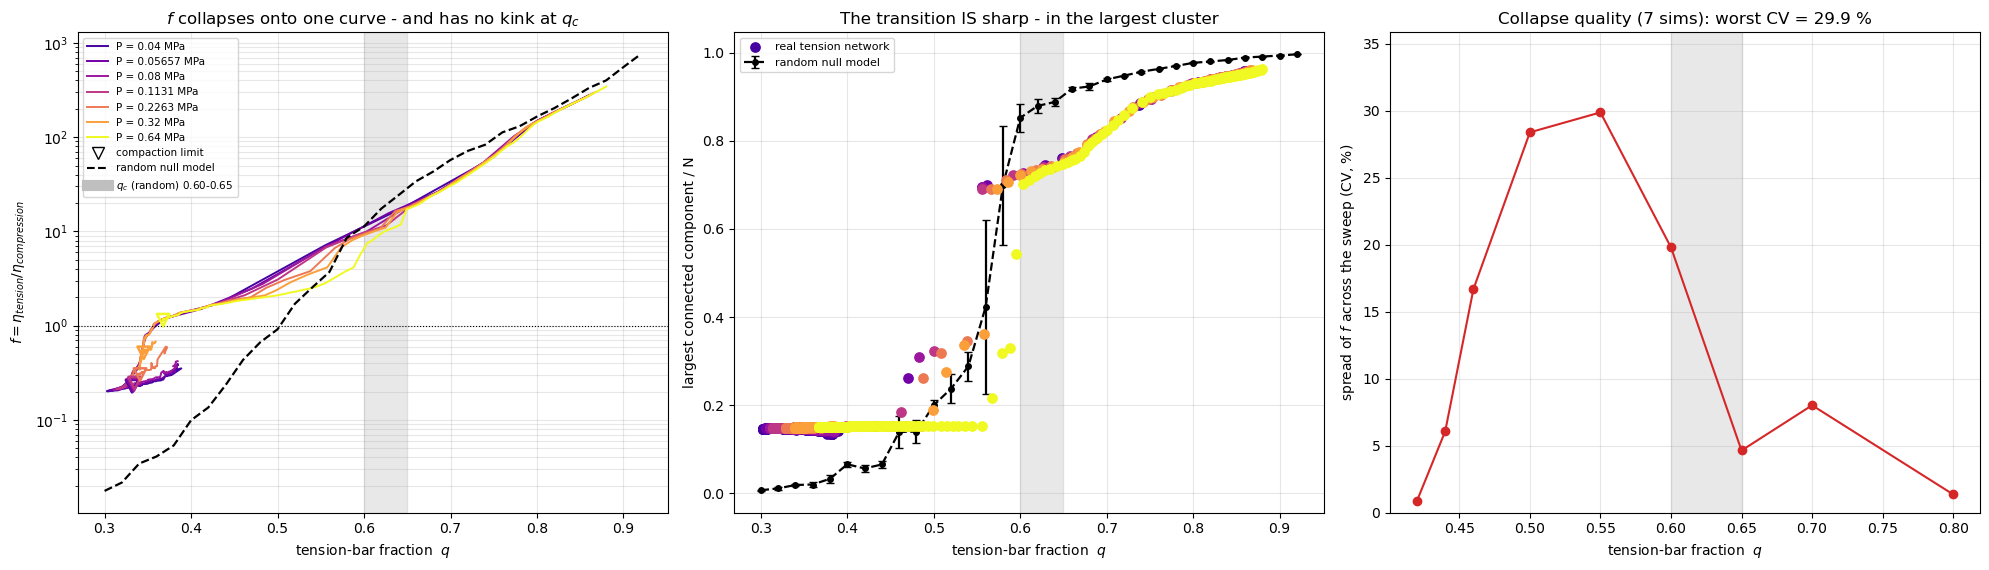

      q     0.42     0.44     0.46     0.50     0.55     0.60     0.65     0.70     0.80
   CV %      0.9      6.1     16.7     28.4     29.9     19.8      4.6      8.0      1.4

f spans 1.60 .. 149, yet at fixed q it varies by at most 29.9% across the sweep => f is a function of the bond fraction.

Random null model - the transition is sharp in LCC, invisible in f:
      q    LCC/N    f_rand
   0.30   0.0072     0.018
   0.32   0.0114     0.022
   0.34   0.0191     0.034
   0.36   0.0202     0.041
   0.38   0.0332     0.054
   0.40   0.0661     0.099
   0.42   0.0567     0.136
   0.44   0.0657     0.235
   0.46   0.1396     0.432
   0.48   0.1402     0.667
   0.50   0.2001     0.916
   0.52   0.2378     1.706
   0.54   0.2883     2.539
   0.56   0.4232     3.717
   0.58   0.6988     8.569
   0.60   0.8520    11.290
   0.62   0.8790    17.473
   0.64   0.8881    24.304
   0.66   0.9182    33.987
   0.68   0.9233    43.153
   0.70   0.9392    57.333
   0.72   0.9477    71.498
   0.74   

In [2]:
def rebuild_bar_fraction_cache():
    def graph_size(g):
        nodes = list(g.nodes())
        if not nodes:
            return 0
        # The reduced graphs use integer node labels, but they are not
        # guaranteed to fit the smaller hard-coded overlay size.
        return max(int(max(nodes)) + 1, g.number_of_nodes())

    def diag(edges, n_overlay):
        if len(edges) == 0 or n_overlay == 0:
            return 0.0, 0.0, 1.0, n_overlay
        a = csr_matrix((np.ones(len(edges)), (edges[:, 0], edges[:, 1])), shape=(n_overlay, n_overlay))
        a = a + a.T
        nc, lab = connected_components(a, directed=False)
        s = np.sort(np.bincount(lab))[::-1]
        rest = s[1:]
        chi = (rest ** 2).sum() / rest.sum() if rest.sum() > 0 else 0.0
        return s[0] / n_overlay, (s[1] / n_overlay if len(s) > 1 else 0.0), chi, nc

    bf_cache = {}
    missing = []
    for sim in SIMS:
        i2 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_I2_3002.pkl'))
        i3 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_I3_BFS_3002.pkl'))
        tp2l = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_TP2_L.pkl'))
        if i2 is None or i3 is None or tp2l is None:
            missing.append(sim)
            continue

        T, C = i2['tension'], i2['compression']
        keys = sorted(T.keys(), key=lambda k: int(k))
        n = len(keys)
        frac_tension = np.full(n, np.nan)
        mean_axial_force = np.full(n, np.nan)
        median_axial_force = np.full(n, np.nan)
        skew_axial_force = np.full(n, np.nan)
        lcc_points = []

        n_overlay = max(graph_size(T[keys[0]]), graph_size(C[keys[0]])) if keys else 0
        for j, ti in enumerate(keys):
            at = np.fromiter((e[2]['axial_force'] for e in T[ti].edges(data=True)), float)
            ac = np.fromiter((e[2]['axial_force'] for e in C[ti].edges(data=True)), float)
            a = np.concatenate([at, ac])
            if len(a) == 0:
                continue
            frac_tension[j] = len(at) / len(a)
            mean_axial_force[j] = a.mean()
            median_axial_force[j] = np.median(a)
            skew_axial_force[j] = 0.0 if len(a) < 3 else float(stats.skew(a))

            et = np.fromiter((x for e in T[ti].edges() for x in e), int).reshape(-1, 2) if len(at) else np.empty((0, 2), dtype=int)
            ec = np.fromiter((x for e in C[ti].edges() for x in e), int).reshape(-1, 2) if len(ac) else np.empty((0, 2), dtype=int)
            lcc_t, lcc2_t, chi_t, nc_t = diag(et, graph_size(T[ti]))
            lcc_c, lcc2_c, chi_c, nc_c = diag(ec, graph_size(C[ti]))
            lcc_points.append({'q': float(frac_tension[j]), 'lcc_tension': float(lcc_t)})

        eft = np.array(i3['global_ef_t'], float)
        efc = np.array(i3['global_ef_c'], float)
        f = np.where(efc != 0, eft / efc, np.nan)
        i_star = first_local_min(np.array(tp2l['shear_mean']))
        frame_f1 = np.nan
        for k in range(1, len(f)):
            if np.isfinite(f[k - 1]) and np.isfinite(f[k]) and f[k - 1] > 1 >= f[k]:
                frame_f1 = k - 1 + (f[k - 1] - 1) / (f[k - 1] - f[k])
                break

        bf_cache[sim] = dict(
            t=np.array(tp2l['t'], float),
            f=f,
            i_star=i_star,
            frame_f1=float(frame_f1),
            n_overlay_nodes=n_overlay,
            lcc_points=lcc_points,
            frac_tension=frac_tension,
            mean_axial_force=mean_axial_force,
            median_axial_force=median_axial_force,
            skew_axial_force=skew_axial_force,
        )

    with open(CACHE_BF, 'wb') as fh:
        pickle.dump(bf_cache, fh)

    if missing:
        print('Missing reduced files for sims:', missing)
    return bf_cache


def plot_percolation_collapse():
    bf = load_pkl(CACHE_BF) or {}
    if not bf or any(sim not in bf for sim in SIMS):
        print('Rebuilding bar-fraction cache from reduced files')
        rebuilt = rebuild_bar_fraction_cache()
        bf = {**bf, **rebuilt}

    null = load_pkl(CACHE_NULL)
    if null is None:
        raise FileNotFoundError(f'Missing {CACHE_NULL}')

    print(f'loaded {CACHE_BF} ({len(bf)} sims) and {CACHE_NULL} '
          f'({null["n_trials"]} trials/point, {null["n_sources"]} BFS sources)')

    fig, (ax, axm, ax2) = plt.subplots(1, 3, figsize=(20, 5.8))
    cmap = plt.get_cmap('plasma', len(SIMS))

    for idx, sim in enumerate(SIMS):
        if sim not in bf or sim not in PRESSURES:
            continue
        q = bf[sim]['frac_tension']
        f = bf[sim]['f']
        i_star = bf[sim]['i_star']
        m = np.isfinite(f) & (f > 0)
        ax.plot(q[m], f[m], color=cmap(idx), lw=1.4, label=f'P = {PRESSURES[sim]:.4g} MPa')
        if np.isfinite(f[i_star]) and f[i_star] > 0:
            ax.scatter(q[i_star], f[i_star], marker='v', s=80, facecolor='none',
                       edgecolor=cmap(idx), linewidths=1.8, zorder=6)

    ax.plot(null['q'], null['f_mean'], 'k--', lw=1.6, zorder=7)
    ax.axhline(1.0, color='k', lw=0.8, ls=':')
    ax.axvspan(*Q_C, color='0.75', alpha=0.35, zorder=0)
    ax.set_yscale('log')
    ax.set_xlabel('tension-bar fraction  $q$')
    ax.set_ylabel(r'$f = \eta_{tension}/\eta_{compression}$')
    ax.set_title('$f$ collapses onto one curve - and has no kink at $q_c$')
    h, l = ax.get_legend_handles_labels()
    h += [Line2D([], [], marker='v', ls='None', mfc='none', mec='k', ms=8),
          Line2D([], [], color='k', ls='--'),
          Line2D([], [], color='0.75', lw=8)]
    l += ['compaction limit', 'random null model', r'$q_c$ (random) 0.60-0.65']
    ax.legend(h, l, loc='upper left', fontsize=7.5)
    ax.grid(True, alpha=0.3, which='both')

    axm.errorbar(null['q'], null['lcc'], yerr=null['lcc_sd'], fmt='k--o', ms=4, lw=1.6,
                 capsize=3, label='random null model')
    for idx, sim in enumerate(SIMS):
        if sim not in bf:
            continue
        pts = bf[sim].get('lcc_points', [])
        if pts:
            axm.scatter([p['q'] for p in pts], [p['lcc_tension'] for p in pts],
                        color=cmap(idx), s=45, zorder=5,
                        label='real tension network' if idx == 1 else None)
    axm.axvspan(*Q_C, color='0.75', alpha=0.35, zorder=0)
    axm.set_xlabel('tension-bar fraction  $q$')
    axm.set_ylabel('largest connected component / N')
    axm.set_title('The transition IS sharp - in the largest cluster')
    axm.legend(fontsize=8, loc='upper left')
    axm.grid(True, alpha=0.3)

    grid = np.array([0.42, 0.44, 0.46, 0.50, 0.55, 0.60, 0.65, 0.70, 0.80])
    vals = []
    for sim in SIMS:
        if sim not in bf:
            continue
        q = bf[sim]['frac_tension']
        f = bf[sim]['f']
        m = np.isfinite(f) & (f > 0)
        if m.sum() < 10 or np.nanmax(q[m]) < grid.max():
            continue
        o = np.argsort(q[m])
        vals.append(np.interp(grid, q[m][o], f[m][o]))
    vals = np.array(vals)
    cv = 100 * vals.std(axis=0, ddof=1) / vals.mean(axis=0)
    ax2.plot(grid, cv, 'o-', color='tab:red')
    ax2.axvspan(*Q_C, color='0.75', alpha=0.35, zorder=0)
    ax2.set_xlabel('tension-bar fraction  $q$')
    ax2.set_ylabel('spread of $f$ across the sweep (CV, %)')
    ax2.set_title(f'Collapse quality ({vals.shape[0]} sims): worst CV = {cv.max():.1f} %')
    ax2.set_ylim(0, max(15, cv.max() * 1.2))
    ax2.grid(True, alpha=0.3)

    fig.tight_layout()
    out_png = 'SIM_3000s_plot16_f_collapse.png'
    fig.savefig(out_png, dpi=200, bbox_inches='tight')
    plt.show()

    print(f"{'q':>7}" + ''.join(f'{v:>9.2f}' for v in grid))
    print(f"{'CV %':>7}" + ''.join(f'{v:>9.1f}' for v in cv))
    print(f"\nf spans {vals.min():.2f} .. {vals.max():.0f}, yet at fixed q it varies by at most "
          f"{cv.max():.1f}% across the sweep => f is a function of the bond fraction.")
    print('\nRandom null model - the transition is sharp in LCC, invisible in f:')
    print(f"{'q':>7}{'LCC/N':>9}{'f_rand':>10}")
    for qq, ll, ff in zip(null['q'], null['lcc'], null['f_mean']):
        print(f'{qq:>7.2f}{ll:>9.4f}{ff:>10.3f}')
    print('   LCC/N rises ~40x across q=0.44->0.72; f_rand rises smoothly with no kink at q_c.')
    print(f'Saved {out_png}')

plot_percolation_collapse()
